---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 8. Зв'язані коливальні контури. Чотириполюсники</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Зв'язані коливальні контури та взаємна індуктивність</li>
  <li>Чотириполюсники</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 8 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Зв'язані коливальні контури та взаємна індуктивність](#mutual-inductance)
* [Чотириполюсники](#two-port)
* [📌 Підсумок теми](#topic-summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---
## Зв'язані коливальні контури та взаємна індуктивність <a class="anchor" id="mutual-inductance"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати рівняння контурних струмів для зв'язаних контурів
> - Пояснювати вплив коефіцієнта зв'язку $k$ на характеристики системи
> - Розраховувати резонансні частоти зв'язаних контурів
> - Оцінювати смугу пропускання смугового фільтра на зв'язаних контурах

</div>

### Система двох зв'язаних контурів

$$\begin{cases}
I_1\left(R_1 + j\omega L_1 + \frac{1}{j\omega C_1}\right) - I_2 \cdot j\omega M = V_{in} \\
I_2\left(R_2 + R_L + j\omega L_2 + \frac{1}{j\omega C_2}\right) - I_1 \cdot j\omega M = 0
\end{cases}$$

де $M = k\sqrt{L_1 L_2}$ — взаємна індуктивність, $k \in [0, 1]$ — коефіцієнт зв'язку.

| Режим | Значення k | Форма АЧХ |
|-------|-----------|----------|
| Слабкий зв'язок | $k < k_{opt}$ | Один пік, вузька смуга |
| Оптимальний зв'язок | $k = k_{opt} = 1/Q$ | Плоска вершина, максимальна вибірковість |
| Сильний зв'язок | $k > k_{opt}$ | Два піки, розщеплення резонансу |

**Числовий приклад.** Задамо параметри двох зв'язаних контурів (індуктивності, ємності, опори, коефіцієнт зв'язку $k = 0{,}5$) і запишемо рівняння контурних струмів з урахуванням взаємної індуктивності $M = k\sqrt{L_1L_2}$. SymPy розв'язує систему відносно $I_1$ та $I_2$.

In [2]:
# Крок 1: параметри кола
Vin_s = 100;

R1_s = 0.1;
R2_s = 0.1;

RL_s = 1;

L1_s = 10e-6;
L2_s = 10e-6;

k=0.5;

M_s = k*np.sqrt(L1_s*L2_s)

f_s = 5000;

C1_s = 1/(L1_s * np.power((2*np.pi*f_s),2));
C2_s = 1/(L2_s * np.power((2*np.pi*f_s),2));

Vin = smp.symbols('V_{in}')
R1 = smp.symbols('R_{1}')
R2 = smp.symbols('R_{2}')
RL = smp.symbols('R_{L}')
L1 = smp.symbols('L_{1}')
L2 = smp.symbols('L_{2}')
C1 = smp.symbols('C_{1}')
C2 = smp.symbols('C_{2}')
M = smp.symbols('M_{12}')
W = smp.symbols('w')
f = smp.symbols('f')

I1 = smp.symbols('I1')
I2 = smp.symbols('I2')

# Крок 2: система рівнянь
eq = [ -Vin+I1*(R1+I*W*L1+1/(I*W*C1))-I2*(I*W*M), I2*(R2+RL+I*W*L2+1/(I*W*C2))-I1*(I*W*M)]

# Крок 3: розв'язуємо систему рівнянь
sol = smp.solve(eq, [I1, I2])
sol

{I1: (-I*C_{1}*C_{2}*L_{2}*V_{in}*w**3 - C_{1}*C_{2}*R_{2}*V_{in}*w**2 - C_{1}*C_{2}*R_{L}*V_{in}*w**2 + I*C_{1}*V_{in}*w)/(C_{1}*C_{2}*L_{1}*L_{2}*w**4 - I*C_{1}*C_{2}*L_{1}*R_{2}*w**3 - I*C_{1}*C_{2}*L_{1}*R_{L}*w**3 - I*C_{1}*C_{2}*L_{2}*R_{1}*w**3 - C_{1}*C_{2}*M_{12}**2*w**4 - C_{1}*C_{2}*R_{1}*R_{2}*w**2 - C_{1}*C_{2}*R_{1}*R_{L}*w**2 - C_{1}*L_{1}*w**2 + I*C_{1}*R_{1}*w - C_{2}*L_{2}*w**2 + I*C_{2}*R_{2}*w + I*C_{2}*R_{L}*w + 1),
 I2: -I*C_{1}*C_{2}*M_{12}*V_{in}*w**3/(C_{1}*C_{2}*L_{1}*L_{2}*w**4 - I*C_{1}*C_{2}*L_{1}*R_{2}*w**3 - I*C_{1}*C_{2}*L_{1}*R_{L}*w**3 - I*C_{1}*C_{2}*L_{2}*R_{1}*w**3 - C_{1}*C_{2}*M_{12}**2*w**4 - C_{1}*C_{2}*R_{1}*R_{2}*w**2 - C_{1}*C_{2}*R_{1}*R_{L}*w**2 - C_{1}*L_{1}*w**2 + I*C_{1}*R_{1}*w - C_{2}*L_{2}*w**2 + I*C_{2}*R_{2}*w + I*C_{2}*R_{L}*w + 1)}

Рівняння першого контуру: власний імпеданс першого контуру і ЕРС взаємоіндукції $j\omega M I_2$ від другого контуру.

In [3]:
eq[0]

I1*(I*L_{1}*w + R_{1} - I/(C_{1}*w)) - I*I2*M_{12}*w - V_{in}

Рівняння другого контуру (з навантаженням $R_L$): ЕРС взаємоіндукції $j\omega M I_1$ — це єдине «джерело» для другого контуру.

In [4]:
eq[1]

-I*I1*M_{12}*w + I2*(I*L_{2}*w + R_{2} + R_{L} - I/(C_{2}*w))

Розв'язок для струму первинного контуру $I_1$:

In [5]:
sol[I1]

(-I*C_{1}*C_{2}*L_{2}*V_{in}*w**3 - C_{1}*C_{2}*R_{2}*V_{in}*w**2 - C_{1}*C_{2}*R_{L}*V_{in}*w**2 + I*C_{1}*V_{in}*w)/(C_{1}*C_{2}*L_{1}*L_{2}*w**4 - I*C_{1}*C_{2}*L_{1}*R_{2}*w**3 - I*C_{1}*C_{2}*L_{1}*R_{L}*w**3 - I*C_{1}*C_{2}*L_{2}*R_{1}*w**3 - C_{1}*C_{2}*M_{12}**2*w**4 - C_{1}*C_{2}*R_{1}*R_{2}*w**2 - C_{1}*C_{2}*R_{1}*R_{L}*w**2 - C_{1}*L_{1}*w**2 + I*C_{1}*R_{1}*w - C_{2}*L_{2}*w**2 + I*C_{2}*R_{2}*w + I*C_{2}*R_{L}*w + 1)

Розв'язок для струму вторинного контуру $I_2$:

In [6]:
sol[I2]

-I*C_{1}*C_{2}*M_{12}*V_{in}*w**3/(C_{1}*C_{2}*L_{1}*L_{2}*w**4 - I*C_{1}*C_{2}*L_{1}*R_{2}*w**3 - I*C_{1}*C_{2}*L_{1}*R_{L}*w**3 - I*C_{1}*C_{2}*L_{2}*R_{1}*w**3 - C_{1}*C_{2}*M_{12}**2*w**4 - C_{1}*C_{2}*R_{1}*R_{2}*w**2 - C_{1}*C_{2}*R_{1}*R_{L}*w**2 - C_{1}*L_{1}*w**2 + I*C_{1}*R_{1}*w - C_{2}*L_{2}*w**2 + I*C_{2}*R_{2}*w + I*C_{2}*R_{L}*w + 1)

Перетворимо вирази для $I_1$ та $I_2$ на функції Python для чисельних розрахунків:

In [7]:
I1_f = lambdify([Vin, R1, R2, RL, L1, L2, M, C1, C2, W], sol[I1], 'numpy')
I2_f = lambdify([Vin, R1, R2, RL, L1, L2, M, C1, C2, W], sol[I2], 'numpy')

Як струми залежать від коефіцієнта зв'язку $k$? Ліворуч — $|I_1(k)|$ та $|I_2(k)|$, праворуч — нормований струм $|I_2|$.

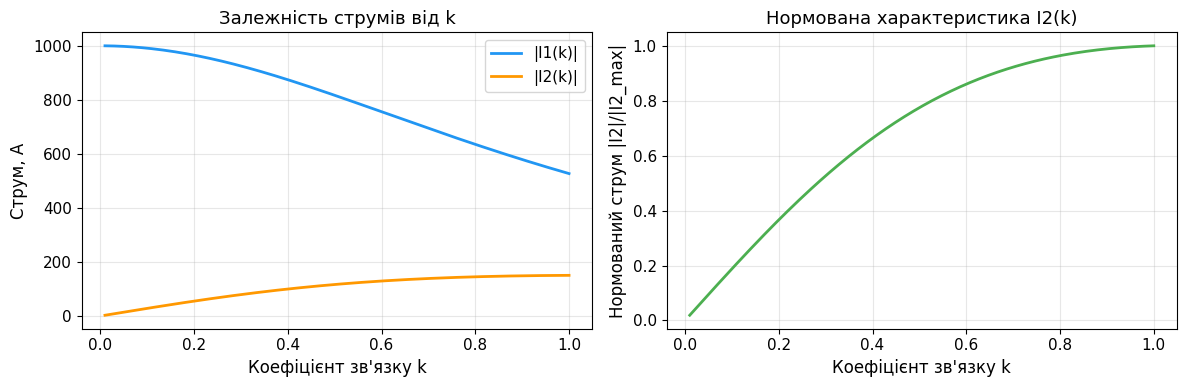

In [8]:
# Вплив коефіцієнта зв'язку k на струми I1 і I2
K_values = np.linspace(0.01, 1.0, 200)
M_values = K_values * np.sqrt(L1_s * L2_s)
Current_1 = np.array([np.abs(I1_f(Vin_s, R1_s, R2_s, RL_s, L1_s, L2_s, M_sub, C1_s, C2_s, 2*np.pi*f_s)) for M_sub in M_values])
Current_2 = np.array([np.abs(I2_f(Vin_s, R1_s, R2_s, RL_s, L1_s, L2_s, M_sub, C1_s, C2_s, 2*np.pi*f_s)) for M_sub in M_values])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_values, Current_1, '#2196F3', lw=2, label='|I1(k)|')
ax1.plot(K_values, Current_2, '#FF9800', lw=2, label='|I2(k)|')
ax1.set_xlabel('Коефіцієнт зв\'язку k'); ax1.set_ylabel('Струм, А')
ax1.set_title('Залежність струмів від k'); ax1.legend()

k_opt = 1 / np.sqrt(f_s * L1_s / R1_s * f_s * L2_s / R2_s)  # наближено
ax2.plot(K_values, Current_2 / Current_2.max(), '#4CAF50', lw=2)
ax2.set_xlabel('Коефіцієнт зв\'язку k')
ax2.set_ylabel('Нормований струм |I2|/|I2_max|')
ax2.set_title('Нормована характеристика I2(k)')
plt.tight_layout(); plt.show()

Окремий графік струму вторинного контуру $|I_2(k)|$:

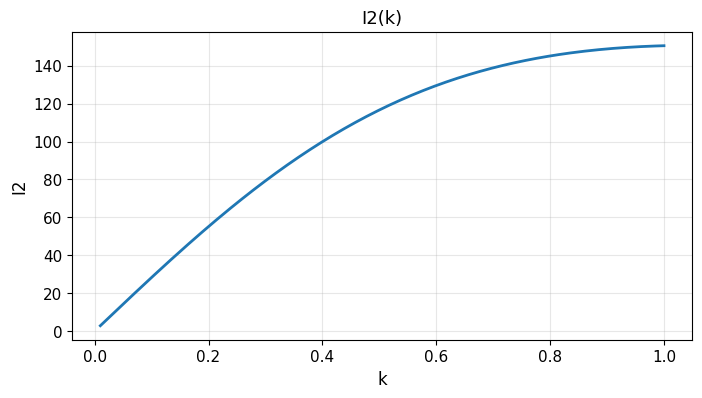

In [9]:
plt.plot(K_values, Current_2)

plt.title('I2(k)')
plt.xlabel('k')
plt.ylabel('I2')
plt.grid(True)
plt.show()

Амплітудно-частотні характеристики вторинного контуру при різних $k$: при сильному зв'язку резонансна крива розщеплюється на два піки.

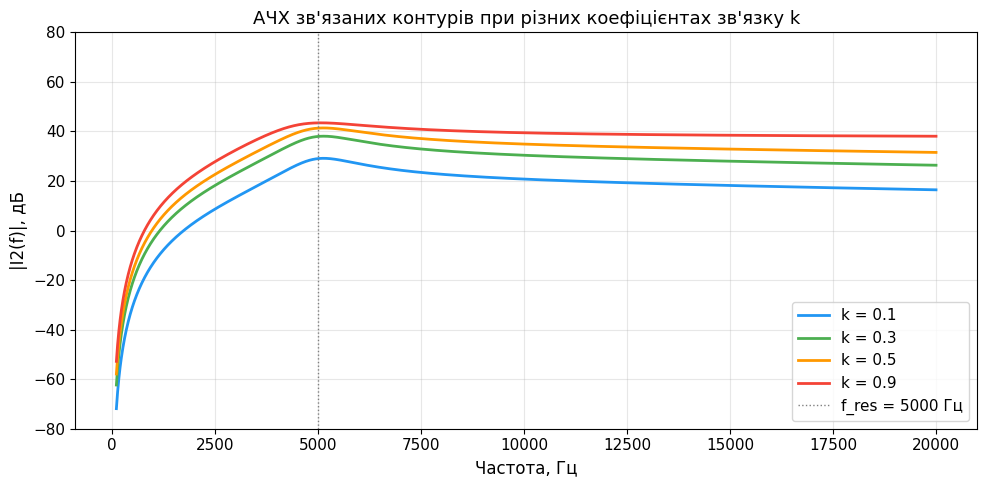

In [10]:
# АЧХ зв'язаних контурів при різних k
f_values = np.linspace(100, 20000, 2000)

fig, ax = plt.subplots(figsize=(10, 5))
for k_val, color in [(0.1, '#2196F3'), (0.3, '#4CAF50'), (0.5, '#FF9800'), (0.9, '#F44336')]:
    M_val = k_val * np.sqrt(L1_s * L2_s)
    I2_freq = np.array([np.abs(I2_f(Vin_s, R1_s, R2_s, RL_s, L1_s, L2_s, M_val, C1_s, C2_s, 2*np.pi*f_sub)) for f_sub in f_values])
    ax.plot(f_values, 20*np.log10(I2_freq + 1e-12), color=color, lw=2, label=f'k = {k_val}')

ax.set_xlabel('Частота, Гц')
ax.set_ylabel('|I2(f)|, дБ')
ax.set_title('АЧХ зв\'язаних контурів при різних коефіцієнтах зв\'язку k')
ax.axvline(f_s, color='gray', ls=':', lw=1, label=f'f_res = {f_s} Гц')
ax.legend(); ax.set_ylim([-80, 80])
plt.tight_layout(); plt.show()

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Явище зв'язаних коливальних контурів з оптимальним $k$ лежить в основі роботи **котушки Тесла** та сучасних систем **бездротової зарядки**. При $k = k_{opt}$ енергія передається між контурами з мінімальними втратами навіть на відстані, що перевищує розміри самих котушок у кілька разів — саме тому Нікола Тесла ще у 1890-х експериментував з передачею енергії без проводів.


</div>


---
### ⚡ Практичне застосування: Зв'язані контури

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Де застосовуються зв'язані коливальні контури:**

| Пристрій | Застосування |
|----------|-------------|
| **ПЧ-фільтр супергетеродинного приймача** | Смуговий фільтр на двох зв'язаних LC-контурах для селекції каналу |
| **Бездротова зарядка (Qi)** | Передача енергії через слабо зв'язані котушки ($k \approx 0{,}1\ldots0{,}5$) |
| **RFID / NFC** | Індуктивний зв'язок антени рідера та мітки |
| **Трансформатор** | Граничний випадок дуже сильного зв'язку ($k \to 1$) |


</div>


### ✅ Питання для самоперевірки: Зв'язані контури

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що таке коефіцієнт зв'язку $k$ і в яких межах він змінюється?</summary>

> **Відповідь:** $k = M/\sqrt{L_1 L_2}$, де $M$ — взаємна індуктивність. $k \in [0, 1]$: $k=0$ — контури незалежні, $k=1$ — ідеальний (без розсіювання) зв'язок.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому при сильному зв'язку АЧХ має два піки («розщеплення» резонансу)?</summary>

> **Відповідь:** При $k > k_{opt}$ у системі з'являються дві власні частоти зв'язаних коливань $\omega_{1,2} = \omega_0/\sqrt{1 \pm k}$ замість однієї. Енергія «перекачується» між контурами швидше, ніж встигає загаснути, тому в спектрі виникають два максимуми симетрично відносно $\omega_0$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чим оптимальний зв'язок відрізняється від слабкого і сильного?</summary>

> **Відповідь:** При $k_{opt} = 1/Q$ АЧХ має єдину плоску вершину — максимальна передача енергії при найширшій рівномірній смузі пропускання. При $k < k_{opt}$ смуга вужча, при $k > k_{opt}$ з'являється провал у центрі (два піки).

</details>


---
### 📝 Задачі для самостійного розв'язання: Зв'язані контури


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Котушки $L_1 = 4$ мГн і $L_2 = 9$ мГн мають коефіцієнт зв'язку $k = 0{,}5$. Знайдіть взаємну індуктивність та еквівалентну індуктивність при узгодженому і зустрічному послідовному ввімкненні.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $M = k\sqrt{L_1L_2} = 3$ мГн; узгоджене: $L_1 + L_2 + 2M = 19$ мГн; зустрічне: $L_1 + L_2 - 2M = 7$ мГн.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Два однакові контури налаштовані на $f_0 = 1$ МГц, добротність кожного $Q = 100$, коефіцієнт зв'язку $k = 0{,}02$. Чи буде АЧХ двогорбою? На яких частотах приблизно розташовані максимуми?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Критичний зв'язок $k_{кр} = 1/Q = 0{,}01 < k$ — АЧХ двогорба. Частоти зв'язку $f_{1,2} \approx \dfrac{f_0}{\sqrt{1 \pm k}}$: $\approx 990$ кГц і $\approx 1010$ кГц.

</details>

---

## Чотириполюсники <a class="anchor" id="two-port"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Визначати чотириполюсник за напругами й струмами на вході та виході
> - Записувати рівняння чотириполюсника у Z-, Y-, H- та A-формах
> - Будувати еквівалентні Т- та П-подібні схеми заміщення
> - Визначати параметри чотириполюсника дослідами короткого замикання і холостого ходу
> - Обчислювати передавальні функції чотириполюсника

</div>

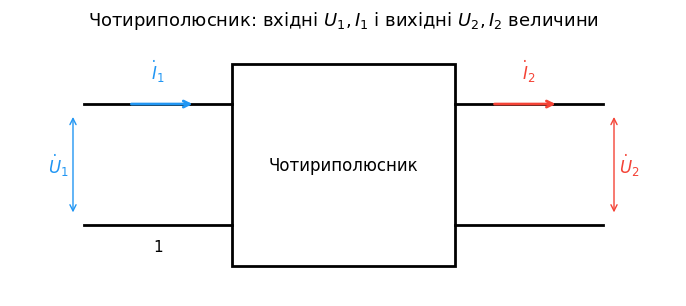

In [11]:
# Чотириполюсник як "чорна скринька" з чотирма затискачами
fig, ax = plt.subplots(figsize=(7, 3.2))
box = plt.Rectangle((2, 0), 3, 2, fill=False, edgecolor='k', lw=2)
ax.add_patch(box)
ax.text(3.5, 1, 'Чотириполюсник', ha='center', va='center', fontsize=12)

# вхідні затискачі 1-1'
ax.plot([0, 2], [1.6, 1.6], 'k-', lw=2)
ax.plot([0, 2], [0.4, 0.4], 'k-', lw=2)
ax.annotate('', xy=(1.5, 1.6), xytext=(0.6, 1.6), arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2))
ax.text(1.0, 1.85, r'$\dot I_1$', color='#2196F3', fontsize=12, ha='center')
ax.text(-0.35, 1.0, r'$\dot U_1$', color='#2196F3', fontsize=12, ha='center', va='center')
ax.annotate('', xy=(-0.15, 1.5), xytext=(-0.15, 0.5), arrowprops=dict(arrowstyle='<->', color='#2196F3', lw=1))

# вихідні затискачі 2-2'
ax.plot([5, 7], [1.6, 1.6], 'k-', lw=2)
ax.plot([5, 7], [0.4, 0.4], 'k-', lw=2)
ax.annotate('', xy=(6.4, 1.6), xytext=(5.5, 1.6), arrowprops=dict(arrowstyle='->', color='#F44336', lw=2))
ax.text(6.0, 1.85, r'$\dot I_2$', color='#F44336', fontsize=12, ha='center')
ax.text(7.35, 1.0, r'$\dot U_2$', color='#F44336', fontsize=12, ha='center', va='center')
ax.annotate('', xy=(7.15, 1.5), xytext=(7.15, 0.5), arrowprops=dict(arrowstyle='<->', color='#F44336', lw=1))

ax.text(1.0, 0.15, "1", ha='center'); ax.text(1.0, 1.95, "1'", ha='center', color='none')
ax.set_xlim(-1, 8); ax.set_ylim(-0.3, 2.3)
ax.axis('off')
ax.set_title("Чотириполюсник: вхідні $U_1, I_1$ і вихідні $U_2, I_2$ величини")
plt.tight_layout(); plt.show()


### Означення

**Чотириполюсник** — частина електричного кола з чотирма зовнішніми затискачами: парою вхідних ($1-1'$) і парою вихідних ($2-2'$). Зв'язок між чотирма величинами $\dot U_1, \dot I_1, \dot U_2, \dot I_2$ описують **два незалежних рівняння** — з шести можливих пар «вхід-вихід» історично використовують чотири основні форми запису.

### Форми запису рівнянь чотириполюсника

| Форма | Рівняння | Параметри | Фізичний зміст параметрів |
|-------|----------|-----------|---------------------------|
| **Z (опору)** | $\dot U_1 = Z_{11}\dot I_1 + Z_{12}\dot I_2$ <br> $\dot U_2 = Z_{21}\dot I_1 + Z_{22}\dot I_2$ | $Z_{11}, Z_{12}, Z_{21}, Z_{22}$ | Вхідний/вихідний опір і опори передачі (розмірність Ом) |
| **Y (провідності)** | $\dot I_1 = Y_{11}\dot U_1 + Y_{12}\dot U_2$ <br> $\dot I_2 = Y_{21}\dot U_1 + Y_{22}\dot U_2$ | $Y_{11}, Y_{12}, Y_{21}, Y_{22}$ | Вхідна/вихідна провідність і провідності передачі (См) |
| **H (гібридна)** | $\dot U_1 = H_{11}\dot I_1 + H_{12}\dot U_2$ <br> $\dot I_2 = H_{21}\dot I_1 + H_{22}\dot U_2$ | $H_{11}$ [Ом], $H_{12}$ [-], $H_{21}$ [-], $H_{22}$ [См] | Зручна для транзисторів: $H_{11}$ — вхідний опір, $H_{21}$ — коефіцієнт передачі струму |
| **A (передавальна, ABCD)** | $\dot U_1 = A_{11}\dot U_2 - A_{12}\dot I_2$ <br> $\dot I_1 = A_{21}\dot U_2 - A_{22}\dot I_2$ | $A_{11}, A_{22}$ [-], $A_{12}$ [Ом], $A_{21}$ [См] | Зручна для каскадного (послідовного) з'єднання чотириполюсників — матриці просто перемножуються |

Для **зворотних (пасивних, без залежних джерел)** чотириполюсників параметри пов'язані умовою взаємності: $Z_{12}=Z_{21}$, $Y_{12}=Y_{21}$, $A_{11}A_{22}-A_{12}A_{21}=1$.

### Еквівалентні схеми заміщення

Будь-який лінійний пасивний чотириполюсник із трьома незалежними опорами можна замінити **Т-подібною** або **П-подібною** схемою:

$$\text{Т-схема: } Z_a = Z_{11}-Z_{12}, \quad Z_b = Z_{22}-Z_{12}, \quad Z_c = Z_{12}$$

де $Z_a$ — поздовжня вітка на вході, $Z_b$ — поздовжня вітка на виході, $Z_c$ — спільна (поперечна) вітка між ними. Для П-схеми аналогічно виражають провідності через Y-параметри.


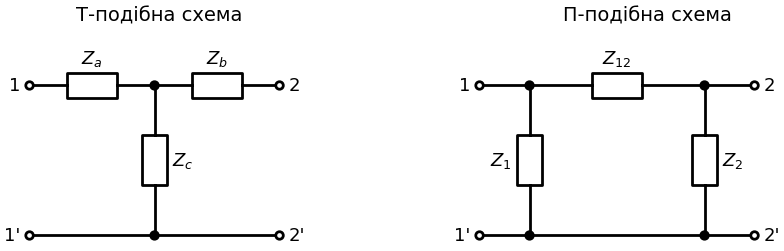

In [12]:
# Schemdraw: Т-подібна та П-подібна еквівалентні схеми чотириполюсника
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=2.5) as d:
        # Т-подібна схема
        p1 = d.add(elm.Dot(open=True).label('1', loc='left'))
        d.add(elm.Resistor().right().label('$Z_a$'))
        m = d.add(elm.Dot())
        d.add(elm.Resistor().right().label('$Z_b$'))
        p2 = d.add(elm.Dot(open=True).label('2', loc='right'))
        d.add(elm.Resistor().at(m.center).down(3).label('$Z_c$', loc='bottom'))
        d.add(elm.Dot())
        d.add(elm.Line().left().tox(p1.center))
        d.add(elm.Dot(open=True).label("1'", loc='left'))
        d.add(elm.Line().at((m.center[0], m.center[1] - 3)).right().tox(p2.center))
        d.add(elm.Dot(open=True).label("2'", loc='right'))
        d.add(elm.Label().at((m.center[0], 1.3)).label('Т-подібна схема', fontsize=14))

        # П-подібна схема
        q1 = d.add(elm.Dot(open=True).at((9, 0)).label('1', loc='left'))
        d.add(elm.Line().right(1))
        l = d.add(elm.Dot())
        d.add(elm.Resistor().right(3.5).label('$Z_{12}$'))
        r = d.add(elm.Dot())
        d.add(elm.Line().right(1))
        q2 = d.add(elm.Dot(open=True).label('2', loc='right'))
        d.add(elm.Resistor().at(l.center).down(3).label('$Z_1$', loc='top'))
        d.add(elm.Dot())
        d.add(elm.Resistor().at(r.center).down(3).label('$Z_2$', loc='bottom'))
        d.add(elm.Dot())
        d.add(elm.Line().at((q1.center[0], -3)).right().tox(q2.center))
        d.add(elm.Dot(open=True).at((q1.center[0], -3)).label("1'", loc='left'))
        d.add(elm.Dot(open=True).at((q2.center[0], -3)).label("2'", loc='right'))
        d.add(elm.Label().at((12.25, 1.3)).label('П-подібна схема', fontsize=14))
else:
    print('Встановіть schemdraw: pip install schemdraw')

### Експериментальне визначення параметрів: холостий хід і коротке замикання

Параметри чотириполюсника визначають, вимірюючи вхідні/вихідні напруги і струми у двох режимах:

- **Холостий хід (ХХ) на виході** ($\dot I_2 = 0$): дає параметри при розімкненому виході —
  $$Z_{11} = \left.\dfrac{\dot U_1}{\dot I_1}\right|_{\dot I_2=0}, \qquad Z_{21} = \left.\dfrac{\dot U_2}{\dot I_1}\right|_{\dot I_2=0}$$
- **Коротке замикання (КЗ) на виході** ($\dot U_2 = 0$): дає Y-параметри —
  $$Y_{11} = \left.\dfrac{\dot I_1}{\dot U_1}\right|_{\dot U_2=0}, \qquad Y_{21} = \left.\dfrac{\dot I_2}{\dot U_1}\right|_{\dot U_2=0}$$

Аналогічно, повторюючи обидва досліди з боку виходу (подаючи джерело в коло $2-2'$, а $1-1'$ розмикаючи або замикаючи), знаходять $Z_{22}, Z_{12}$ і $Y_{22}, Y_{12}$.

**Гібридні (H) параметри транзистора** — практичний приклад тієї самої ідеї: $h_{11}$ вимірюють при короткозамкненому виході ($\dot U_2=0$) як вхідний опір, а $h_{22}$ — при розімкненому вході ($\dot I_1=0$) як вихідну провідність. Саме тому довідникові H-параметри транзисторів завжди супроводжуються позначенням режиму вимірювання (індекс «к.з.» або «х.х.»).

### Передавальні функції чотириполюсника

$$\dot K_U(j\omega) = \dfrac{\dot U_2}{\dot U_1}, \qquad \dot K_I(j\omega) = \dfrac{\dot I_2}{\dot I_1}, \qquad Z_{пер}(j\omega) = \dfrac{\dot U_2}{\dot I_1}, \qquad Y_{пер}(j\omega) = \dfrac{\dot I_2}{\dot U_1}$$

Найважливіша на практиці — передавальна функція за напругою $\dot K_U(j\omega)$: саме її АЧХ і ФЧХ визначають фільтр (ФНЧ, ФВЧ, смуговий) — див. приклад RC-кола нижче, розглянутого як чотириполюсник у розімкненому режимі ($\dot I_2 = 0$, холостий хід на виході).


K_U(jw) = -I/(C*R*omega - I)


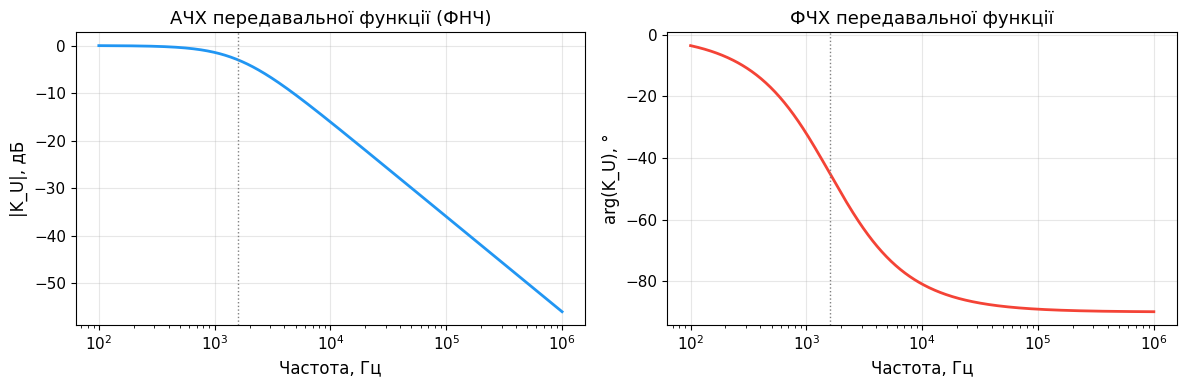

Частота зрізу fc = 1/(2πRC) = 1591.5 Гц (на цій частоті |K_U| = 1/√2, arg = -45°)


In [13]:
# RC-коло як чотириполюсник: передавальна функція K_U(jw) при холостому ході на виході
R_2p, C_2p = smp.symbols('R C', positive=True)
w_2p = smp.symbols('omega', positive=True)
s_2p = smp.I*w_2p

Zc = 1/(s_2p*C_2p)
K_U = Zc / (R_2p + Zc)                       # дільник напруги, I2=0 (х.х.)
K_U = smp.simplify(K_U)
print('K_U(jw) =', K_U)

R_val, C_val = 1000.0, 100e-9
K_U_f = smp.lambdify(w_2p, K_U.subs({R_2p: R_val, C_2p: C_val}), 'numpy')

f_arr = np.logspace(2, 6, 500)
w_arr = 2*np.pi*f_arr
K_arr = K_U_f(w_arr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogx(f_arr, 20*np.log10(np.abs(K_arr)), color='#2196F3', lw=2)
ax1.set_xlabel('Частота, Гц'); ax1.set_ylabel('|K_U|, дБ'); ax1.set_title('АЧХ передавальної функції (ФНЧ)')
ax2.semilogx(f_arr, np.degrees(np.angle(K_arr)), color='#F44336', lw=2)
ax2.set_xlabel('Частота, Гц'); ax2.set_ylabel('arg(K_U), °'); ax2.set_title('ФЧХ передавальної функції')
fc = 1/(2*np.pi*R_val*C_val)
for ax in (ax1, ax2):
    ax.axvline(fc, color='gray', ls=':', lw=1)
plt.tight_layout(); plt.show()
print(f'Частота зрізу fc = 1/(2πRC) = {fc:.1f} Гц (на цій частоті |K_U| = 1/√2, arg = -45°)')


---
### ⚡ Практичне застосування: Чотириполюсники

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Застосування | Форма опису |
|--------------|-------------|
| **Малосигнальна модель транзистора** | H-параметри ($h_{11}, h_{12}, h_{21}, h_{22}$) — стандарт довідників |
| **Каскадне з'єднання підсилювальних каскадів чи фільтрів** | A-параметри (ABCD) — матриці каскадів перемножуються |
| **Узгоджувальні кола антен, лінії передачі** | Z- або Y-параметри, часто разом з S-параметрами (на надвисоких частотах) |
| **Фільтри (ФНЧ, ФВЧ, смугові)** | Передавальна функція $K_U(j\omega)$ чотириполюсника в режимі холостого ходу на виході |

</div>

---
### ✅ Питання для самоперевірки: Чотириполюсники

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому для опису чотириполюсника достатньо лише двох рівнянь, хоча величин чотири?</summary>

> **Відповідь:** $\dot U_1, \dot I_1, \dot U_2, \dot I_2$ пов'язані внутрішньою структурою кола — незалежних серед них лише дві (наприклад, $\dot I_1, \dot I_2$), а решта виражаються через них лінійними рівняннями з параметрами чотириполюсника.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Який дослід (ХХ чи КЗ) дає Y-параметри, а який Z-параметри?</summary>

> **Відповідь:** Z-параметри вимірюють у режимі холостого ходу (розімкнений вихід, $I_2=0$) — саме тоді рівняння Z-форми напряму дають $Z_{11}=U_1/I_1$. Y-параметри вимірюють у режимі короткого замикання виходу ($U_2=0$), коли рівняння Y-форми дають $Y_{11}=I_1/U_1$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому саме A-параметри (ABCD) зручні при каскадному з'єднанні кількох чотириполюсників?</summary>

> **Відповідь:** Вихідні величини $U_2, I_2$ першого чотириполюсника є вхідними величинами $U_1, I_1$ другого, тому загальна матриця каскаду дорівнює добутку матриць A окремих ланок — це прямий наслідок форми запису рівнянь через $U_2, I_2$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Що показує передавальна функція $K_U(j\omega)$ у режимі холостого ходу?</summary>

> **Відповідь:** Відношення комплексної амплітуди вихідної напруги до вхідної при розімкненому виході ($I_2=0$) — саме вона визначає АЧХ і ФЧХ кола як фільтра чи підсилювача.

</details>

---
### 📝 Задачі для самостійного розв'язання: Чотириполюсники


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Т-подібний чотириполюсник: поздовжні опори $Z_1 = Z_2 = 10$ Ом, поперечний $Z_3 = 20$ Ом. Знайдіть $Z$-параметри та $A$-параметри. Перевірте умову взаємності.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $Z_{11} = Z_1 + Z_3 = 30$, $Z_{22} = 30$, $Z_{12} = Z_{21} = 20$ Ом.
> $A = Z_{11}/Z_{21} = 1{,}5$; $B = \Delta_Z/Z_{21} = 25$ Ом; $C = 1/Z_{21} = 0{,}05$ См; $D = 1{,}5$. $AD - BC = 2{,}25 - 1{,}25 = 1$ ✔.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** RC-фільтр нижніх частот: $R = 1$ кОм, $C = 159$ нФ (вихід на холостому ході). Знайдіть частоту зрізу, $K_U$ на частоті зрізу і на 10 кГц.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f_c = \dfrac{1}{2\pi RC} \approx 1$ кГц; на $f_c$: $|K_U| = 1/\sqrt2 \approx 0{,}707$ (−3 дБ), $\varphi = -45°$; на 10 кГц: $|K_U| \approx 0{,}0996$ (≈ −20 дБ).

</details>

---

### 📌 Підсумок теми <a class="anchor" id="topic-summary"></a>

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Поняття | Формула |
|---|---|
| Взаємна індуктивність | $M = k\sqrt{L_1L_2}$, $\;0 \le k \le 1$ |
| Рівняння зв'язаних контурів | $\dot I_1 Z_1 - j\omega M\dot I_2 = \dot U$, $\;-j\omega M\dot I_1 + \dot I_2 Z_2 = 0$ |
| Внесений опір | $Z_{вн} = \dfrac{(\omega M)^2}{Z_2}$ ($Z_1$, $Z_2$ — власні опори контурів) |
| Оптимальний (критичний) зв'язок | $k_{опт} = 1/Q$; при $k > 1/Q$ АЧХ двогорба |
| Z- і Y-форми | $\dot U_1 = Z_{11}\dot I_1 + Z_{12}\dot I_2$; $\;\dot I_1 = Y_{11}\dot U_1 + Y_{12}\dot U_2$ |
| A-форма | $\dot U_1 = A_{11}\dot U_2 - A_{12}\dot I_2$, $\;\dot I_1 = A_{21}\dot U_2 - A_{22}\dot I_2$ |
| Взаємність | $Z_{12} = Z_{21}$, $\;A_{11}A_{22} - A_{12}A_{21} = 1$ |
| Каскадне з'єднання | $[A] = [A'][A'']$ |
| Передавальні функції | $\dot K_U = \dot U_2/\dot U_1$, $\;\dot K_I = \dot I_2/\dot I_1$ |

**Головні висновки.** (1) Через взаємну індуктивність другий контур «вноситься» в перший як додатковий опір, що змінює резонансну частоту й добротність. (2) Ступінь зв'язку визначає форму АЧХ: слабкий зв'язок — один пік, критичний — плоска вершина, сильний — два піки; система зв'язаних контурів дає кращу прямокутність АЧХ, ніж один контур. (3) Чотириполюсник повністю описується чотирма параметрами, які визначають з дослідів холостого ходу і короткого замикання; A-форма зручна для каскадів, оскільки їхні матриці перемножуються.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 7. Параметри синусоїдного струму. Потужність і резонанс](Тема_07_Потужність_та_резонанс.ipynb) &nbsp;|&nbsp; [Тема 9. Трифазні кола](Тема_09_Трифазні_кола.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
